In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split #For splitting the data into train & test
from sklearn.linear_model import LinearRegression #Linear regression model
from sklearn.metrics import mean_squared_error #Metric for regression MSE
import numpy as np

import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("data.csv")
data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'

In [ ]:
data.shape

In [ ]:
column_names = data.columns.tolist()
print("Column Names:")
for column_name in column_names:
    print(column_name)

In [ ]:
# List of important parameters to keep
important_parameters = [
    'CUSTOM.updateTime [local]',
    'OSD.latitude', 'OSD.longitude', 'OSD.height [ft]', 'OSD.hSpeed [MPH]',
    'OSD.pitch','OSD.roll','OSD.yaw',
    'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder'
]

# Keep only the important parameters
data_filtered = data[important_parameters]

In [5]:
data_filtered.shape

(2577, 9)

In [6]:
data_filtered.head(5)

,CUSTOM.updateTime [local],OSD.latitude,OSD.longitude,OSD.height [ft],OSD.hSpeed [MPH],RC.aileron,RC.elevator,RC.throttle,RC.rudder
0,56:01.2,7.498430,80.353166,0.0,NaN,1024,1024,1024,1024
1,56:01.3,7.498430,80.353166,0.0,NaN,1024,1024,1024,1024
2,56:01.4,7.498430,80.353166,0.0,NaN,1024,1024,1024,1024
3,56:01.5,7.498430,80.353166,0.0,NaN,1024,1024,1024,1024
4,56:01.6,7.498429,80.353166,0.0,NaN,1024,1024,1024,1024


In [8]:
df=data_filtered

# Create a GeoDataFrame from the DataFrame with latitude and longitude
geometry = [Point(xy) for xy in zip(df['OSD.longitude'], df['OSD.latitude'])]
geo_df = gpd.GeoDataFrame(df, geometry=geometry)

# Get the bounding box of the drone path
minx, miny, maxx, maxy = geo_df.geometry.total_bounds

# Set the buffer for zooming (adjust as needed)
buffer_percent = 0.1
x_buffer = (maxx - minx) * buffer_percent
y_buffer = (maxy - miny) * buffer_percent

# Plot the drone path with zoom
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(minx - x_buffer, maxx + x_buffer)
ax.set_ylim(miny - y_buffer, maxy + y_buffer)

# Plot the world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.plot(ax=ax, color='lightgrey')

# Plot the drone path on top of the world map
geo_df.plot(ax=ax, marker='o', color='red', markersize=10, label='Drone Path')

# Customize the plot
plt.title('Drone Path (Zoomed In)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

# Show the plot
plt.show()


NameError: name 'Point' is not defined

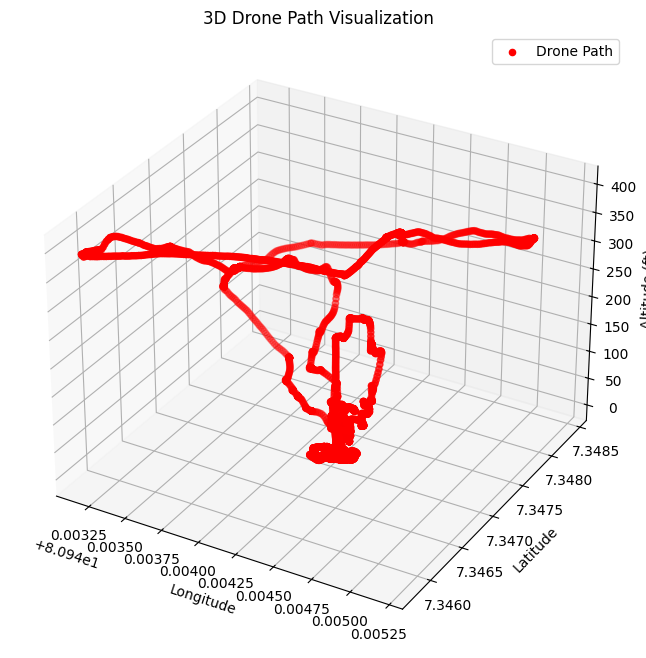

In [22]:
# Create a 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the drone path
ax.scatter(df['OSD.longitude'], df['OSD.latitude'], df['OSD.height [ft]'], c='red', marker='o', label='Drone Path')

# Customize the plot
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude (ft)')
ax.set_title('3D Drone Path Visualization')
ax.legend()

# Show the plot
plt.show()


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assuming 'your_file.csv' is the name of your CSV file
df = pd.read_csv('data.csv')

# Selecting relevant features and target variable
features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder', 'RC.mode']
target = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  # You can choose other strategies like 'median' or 'most_frequent'
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Handling missing values in target variables (if any)
# For simplicity, let's drop rows with missing target values
y_train = y_train.dropna().reset_index(drop=True)
X_train_imputed = X_train_imputed[y_train.index]

# Creating and training the Random Forest Regression model for longitude
model_longitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_longitude.fit(X_train_imputed, y_train['OSD.longitude'])

# Creating and training the Random Forest Regression model for latitude
model_latitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_latitude.fit(X_train_imputed, y_train['OSD.latitude'])

# Creating and training the Random Forest Regression model for altitude
model_altitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_altitude.fit(X_train_imputed, y_train['OSD.height [ft]'])

# Making predictions on the test set
longitude_pred = model_longitude.predict(X_test_imputed)
latitude_pred = model_latitude.predict(X_test_imputed)
altitude_pred = model_altitude.predict(X_test_imputed)

# Evaluating the models
mse_longitude = mean_squared_error(y_test['OSD.longitude'], longitude_pred)
r2_longitude = r2_score(y_test['OSD.longitude'], longitude_pred)

mse_latitude = mean_squared_error(y_test['OSD.latitude'], latitude_pred)
r2_latitude = r2_score(y_test['OSD.latitude'], latitude_pred)

mse_altitude = mean_squared_error(y_test['OSD.height [ft]'], altitude_pred)
r2_altitude = r2_score(y_test['OSD.height [ft]'], altitude_pred)

print(f'Mean Squared Error (Longitude): {mse_longitude}, R-squared (Longitude): {r2_longitude}')
print(f'Mean Squared Error (Latitude): {mse_latitude}, R-squared (Latitude): {r2_latitude}')
print(f'Mean Squared Error (Altitude): {mse_altitude}, R-squared (Altitude): {r2_altitude}')


C:\Users\User\AppData\Local\Temp\ipykernel_12976\3062643901.py:9: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


Mean Squared Error (Longitude): 7.552163850257975e-08, R-squared (Longitude): -4.169148424937319e-05
Mean Squared Error (Latitude): 1.1766050503964645e-07, R-squared (Latitude): -0.000697567863698012
Mean Squared Error (Altitude): 14082.213564842228, R-squared (Altitude): -0.0004614138957454994


C:\Users\User\AppData\Local\Temp\ipykernel_12976\2858604248.py:10: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


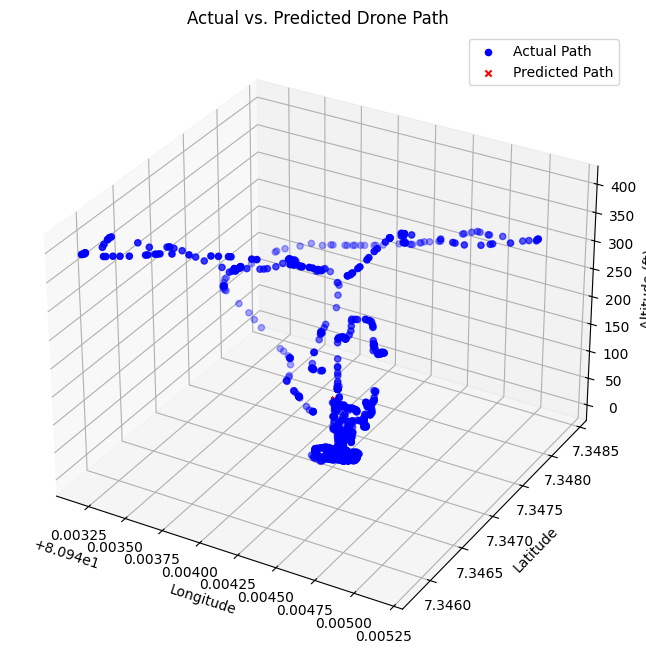

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

# Assuming 'your_file.csv' is the name of your CSV file
df = pd.read_csv('data.csv')

# Selecting relevant features and target variable
features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder', 'RC.mode']
target = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Handling missing values in target variables (if any)
y_train = y_train.dropna().reset_index(drop=True)
X_train_imputed = X_train_imputed[y_train.index]

# Creating and training the Random Forest Regression model for longitude
model_longitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_longitude.fit(X_train_imputed, y_train['OSD.longitude'])

# Creating and training the Random Forest Regression model for latitude
model_latitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_latitude.fit(X_train_imputed, y_train['OSD.latitude'])

# Creating and training the Random Forest Regression model for altitude
model_altitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_altitude.fit(X_train_imputed, y_train['OSD.height [ft]'])

# Making predictions on the test set
longitude_pred = model_longitude.predict(X_test_imputed)
latitude_pred = model_latitude.predict(X_test_imputed)
altitude_pred = model_altitude.predict(X_test_imputed)

# Create a 3D plot for the predicted drone path
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual drone path
ax.scatter(y_test['OSD.longitude'], y_test['OSD.latitude'], y_test['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')

# Plot the predicted drone path
ax.scatter(longitude_pred, latitude_pred, altitude_pred, c='red', marker='x', label='Predicted Path')

# Customize the plot
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude (ft)')
ax.set_title('Actual vs. Predicted Drone Path')
ax.legend()

# Show the plot
plt.show()


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# Assuming 'your_file.csv' is the name of your CSV file
df = pd.read_csv('data.csv')

# Selecting relevant features and target variable
features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder', 'RC.mode']
target = 'OSD.longitude'

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Creating and training the Random Forest Regression model
model_longitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_longitude.fit(X_train_imputed, y_train)

# Print feature importances
feature_importances = model_longitude.feature_importances_
print('Feature Importances:')
for feature, importance in zip(features, feature_importances):
    print(f'{feature}: {importance}')


C:\Users\User\AppData\Local\Temp\ipykernel_12976\1501183705.py:7: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


Feature Importances:
RC.aileron: 0.25333333333333335
RC.elevator: 0.21333333333333335
RC.throttle: 0.21333333333333335
RC.rudder: 0.32
RC.mode: 0.0


In [9]:
import os
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib.pyplot as plt

# Get the current working directory
current_path = os.getcwd()

# Initialize an empty GeoDataFrame to store all drone paths
all_geo_df = gpd.GeoDataFrame()

# Iterate through all Excel files in the current directory
for filename in os.listdir(current_path):
    if filename.endswith('.xlsx'):
        # Read Excel file into a DataFrame
        df = pd.read_excel(os.path.join(current_path, filename))

        # Create a GeoDataFrame from the DataFrame with latitude and longitude
        geometry = [Point(xy) for xy in zip(df['OSD.longitude'], df['OSD.latitude'])]
        geo_df = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")  # Specify the CRS (Coordinate Reference System)

        # Append the current GeoDataFrame to the overall GeoDataFrame
        all_geo_df = all_geo_df.append(geo_df, ignore_index=True)

# Set the 'geometry' column explicitly
all_geo_df = all_geo_df.set_geometry('geometry')

# Get the bounding box of all drone paths
minx, miny, maxx, maxy = all_geo_df.geometry.total_bounds

# Set the buffer for zooming (adjust as needed)
buffer_percent = 0.1
x_buffer = (maxx - minx) * buffer_percent
y_buffer = (maxy - miny) * buffer_percent

# Plot all drone paths with zoom
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(minx - x_buffer, maxx + x_buffer)
ax.set_ylim(miny - y_buffer, maxy + y_buffer)

# Plot the world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.plot(ax=ax, color='lightgrey')

# Plot all drone paths on top of the world map
all_geo_df.plot(ax=ax, marker='o', color='red', markersize=10, label='Drone Paths')

# Customize the plot
plt.title('All Drone Paths (Zoomed In)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

# Show the plot
plt.show()


ValueError: Unknown column geometry